In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
# sys.path.append('/home/mvargas/code/Huawei/survan')

from deep_lambda_cox import DeepLambdaSA
from lambda_cox import LambdaSA
from baseline_cox import SA

from utils import concordance_index, unroll, get_single_task_dataset, kaplan_meier, pad_to, get_single_target_and_mask, score
import yaml
import jax
import jax.numpy as jnp
import numpy as np
import haiku as hk
import matplotlib.pyplot as plt

In [2]:
config_path = '../configs/config_lastfm.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [3]:
task_id = 'lastfm'
save_fig = False

In [4]:
model = DeepLambdaSA(config, seed=42)

In [5]:
model.data['ts'][11]

49

In [7]:
model.data['seqs'].shape

(992, 53, 83)

In [7]:
train_gen, _ = model.get_train_test()

In [11]:
train_gen.cs.sum()/len(train_gen.cs)

0.7728171799943487

In [8]:
%%time
num_exps = 5
sizes = [.2]

ibs_is = np.zeros((num_exps, len(sizes)))
ibs_lm = np.zeros((num_exps, len(sizes)))

ci_is = np.zeros((num_exps, len(sizes)))
ci_lm = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['landmark'] = False
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        ibs_is[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_is[fold, i] = concordance_index(scores, ts, cs)

        # Landmarking.
        config['landmark'] = True
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        ms = test_gen.mask
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        ibs_lm[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_lm[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.
.
.
.
.
CPU times: user 9min 30s, sys: 1min 51s, total: 11min 21s
Wall time: 5min 48s


In [9]:
%%time

num_exps = 5
sizes = [.2]
size = sizes[0]

bs_0 = np.zeros((num_exps, len(sizes)))
bs_1 = np.zeros((num_exps, len(sizes)))

ci_0 = np.zeros((num_exps, len(sizes)))
ci_1 = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        print(".", end="")
        
        # Landmarking.
        config['lambda_'] = .9
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_1[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)

        scores = model.scores(seqs, q=0.0)
        ci_1[fold, i] = concordance_index(scores, ts, cs)

        # TCSR.
        config['lambda_'] = 0.0
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_0[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_0[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.
.
.
.
.
CPU times: user 13min 20s, sys: 2min 52s, total: 16min 13s
Wall time: 8min 49s


In [15]:
# save_fig = True
save_fig = False

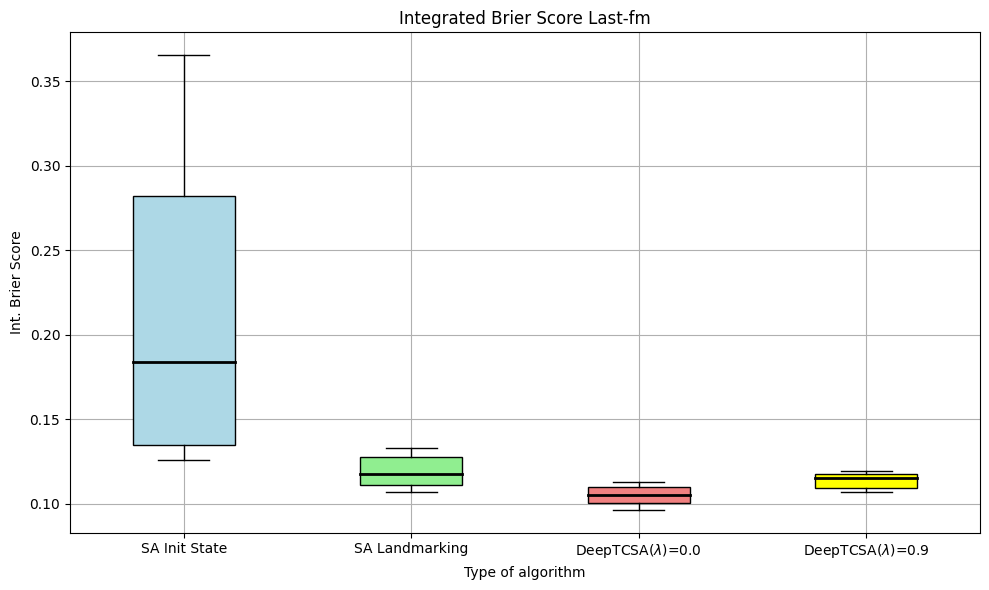

In [12]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
bs_is = ibs_is.reshape(-1)
bs_lm = ibs_lm.reshape(-1)
bs_a9 = bs_1.reshape(-1)
bs_a0 = bs_0.reshape(-1)
boxplot = ax.boxplot([bs_is, bs_lm, bs_a0, bs_a9], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['SA Init State', 'SA Landmarking', r'DeepTCSA($\lambda$)=0.0', r'DeepTCSA($\lambda$)=0.9'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score Last-fm")
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/lastfm/Int_brier_score_task_transformer_static.pdf", format="pdf")

plt.show()


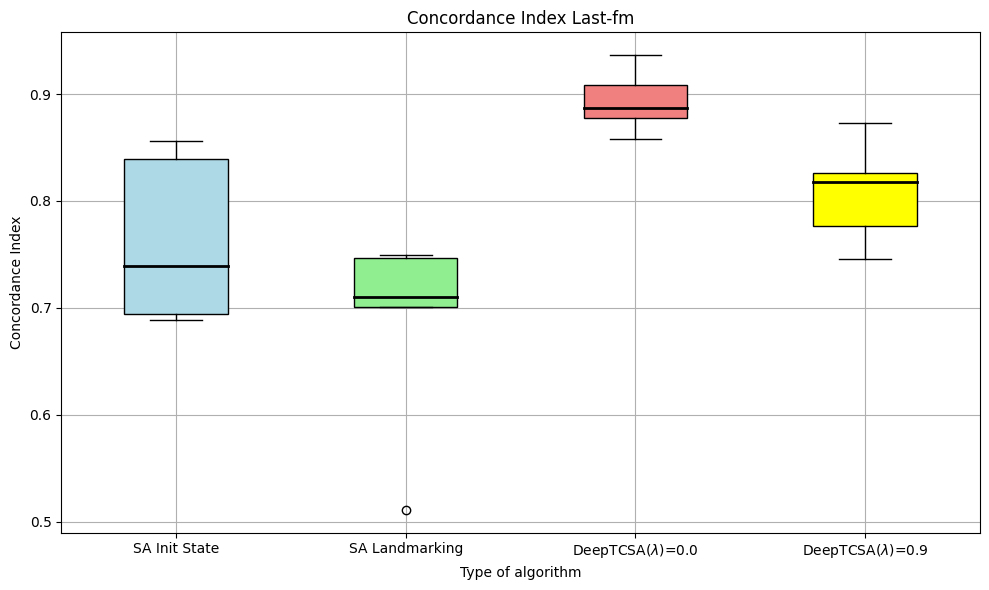

In [13]:


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
ci_is = ci_is.reshape(-1)
ci_lm = ci_lm.reshape(-1)
ci_a9 = ci_1.reshape(-1)
ci_a0 = ci_0.reshape(-1)
boxplot = ax.boxplot([ci_is, ci_lm, ci_a0, ci_a9], medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['SA Init State', 'SA Landmarking', r'DeepTCSA($\lambda$)=0.0', r'DeepTCSA($\lambda$)=0.9'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Concordance Index")
ax.set_title("Concordance Index Last-fm")
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/lastfm/Concordance_idx_task_transformer_static.pdf", format="pdf")

plt.show()


In [114]:
config['landmark'] = True
config['num_epochs'] = 100
config['lambda_'] = 0.0
model = DeepLambdaSA(config, seed=1)

In [115]:
train_gen, test_gen = model.get_train_test(test_size=.2)

In [116]:
train_gen.mask.shape

(794, 53, 53)

In [117]:
loss = model.train(train_gen, test_gen)

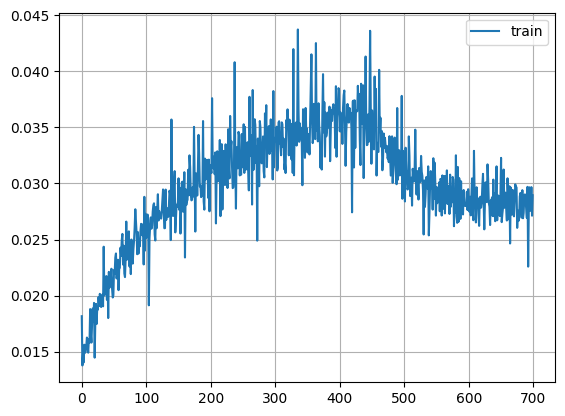

In [118]:
plt.plot(loss, label='train')
# plt.plot(loss[1], label='test')
plt.legend()
plt.grid()

In [119]:
# plt.plot(tr_loss, label='train')
# plt.plot(te_loss, label='test')
# plt.legend()
# plt.grid()

In [120]:
seqs = train_gen.X
ts = train_gen.ts
cs = train_gen.cs
y = train_gen.y

scores = model.scores(seqs, q=0.0)
concordance_index(scores, ts, cs)

0.8565469360065242

In [121]:
seqs_t = test_gen.X
ts_t = test_gen.ts
cs_t = test_gen.cs
y_t = test_gen.y

scores = model.scores(seqs_t, q=0.0)
concordance_index(scores, ts_t, cs_t)

0.8339883753113756

In [101]:
h = model.forward(model.state.params, seqs)

In [102]:
h = jax.nn.sigmoid(h)

In [86]:
h_unc = h[~cs]
h_cen = h[cs]

In [87]:
ts_unc = ts[~cs]
ts_cen = ts[cs]

In [14]:
xs_, ts_, cs_, ms_ = unroll_time(seqs, ts, cs, mask, 53)

NameError: name 'unroll_time' is not defined

In [15]:
ts_[:4]

NameError: name 'ts_' is not defined

In [16]:
beta = model.state.params['cox_linear_model']['beta']
scores = score(beta, seqs[:,0])
concordance_index(scores, ts, cs)

KeyError: 'cox_linear_model'

In [88]:
beta = model.state.params['cox_linear_model']['beta']
scores = score(beta, xs_)
concordance_index(scores, ts_, cs_)

KeyError: 'cox_linear_model'

In [381]:
seqs.reshape(-1, 12).shape

(26288, 12)

In [382]:
ts.shape

(496,)

In [383]:
mask = train_gen.mask

In [384]:
ts[10]

16

In [123]:
surv = model.survival_curve(seqs_t)
model.integrated_brier_score(surv[:,0], ts_t, cs_t)

Array(0.11433763, dtype=float32)

In [90]:
scurves = surv[:,0]

In [91]:
s_cen = scurves[cs]
s_unc = scurves[~cs]

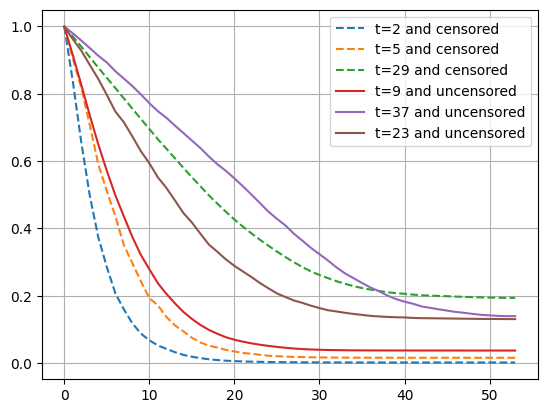

In [92]:
for i in range(3):
    plt.plot(s_cen[i], linestyle='dashed', label=f't={ts_cen[i]} and censored')
for i in range(3):
    plt.plot(s_unc[i], label=f't={ts_unc[i]} and uncensored')
plt.legend()
plt.grid()

In [229]:
model.state.params

{'cox_linear_model': {'alpha': Array([-0.32719988, -0.12144285, -0.32881594,  0.3289866 , -0.31293648,
         -0.31293648, -0.31293648,  0.10455556,  0.4866164 , -0.27725777,
         -0.27725777,  0.548992  , -0.27927053, -0.27927053, -0.27927053,
          0.54990214, -0.25323695, -0.25323695, -0.25323695,  0.5334388 ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ], dtype=float32),
  'beta': Array([ 0.        , -0.12985861, -0.09042235, -0.04513536, -0.02879856,
         -0.07287915, -0.04828871, -0.04231764, -0.02477831, -0.03221218,
          